# 🚀 GoViralIQ
## Notebook 2: Data Cleaning & Feature Engineering
**Project:** Predicting Instagram Engagement & Auditing Algorithmic Fairness Across Creator Niches  
**Author:** Chastity Lewis  
**Course:** CISC 540 — Computational Data Analysis | Mercy University | Spring 2026  

---

### 📌 Notebook Goals
In this notebook we will:
1. Load the raw Instagram dataset from Notebook 1
2. Remove duplicates
3. Handle missing values
4. Remove outliers using the IQR method
5. Normalize numeric features using MinMaxScaler
6. Engineer additional features for ML
7. Save the clean dataset for Notebook 3

---

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#6B21A8', '#D8B4FE', '#1F1F1F', '#F3E8FF', '#9333EA']

print('✅ Libraries loaded!')

✅ Libraries loaded!


## Step 2: Load the Dataset from Notebook 1

In [2]:
# Upload the file saved from Notebook 1
from google.colab import files
uploaded = files.upload()

Saving goviraliq_instagram_raw.csv to goviraliq_instagram_raw.csv


In [3]:
import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'✅ Loaded: {filename}')
print(f'📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

✅ Loaded: goviraliq_instagram_raw.csv
📊 Shape: 1,212 rows × 12 columns


,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level,engagement_rate,viral
0,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium,7.4192,0
1,Post_6,Instagram,#Challenge,Shorts,Australia,1323566,136282,86979,47129,Low,20.4289,0
2,Post_11,Instagram,#Comedy,Live Stream,Germany,4070332,379894,46012,25242,High,11.0838,0
3,Post_27,Instagram,#Gaming,Video,India,4369260,212278,21264,18172,Low,5.7610,0
4,Post_29,Instagram,#Gaming,Live Stream,Canada,1653907,91836,77370,2823,Low,10.4014,0


## Step 3: Remove Duplicates

In [4]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
removed = before - after

print(f'🔁 Rows before: {before:,}')
print(f'🗑️  Duplicates removed: {removed:,}')
print(f'✅ Rows after: {after:,}')

🔁 Rows before: 1,212
🗑️  Duplicates removed: 0
✅ Rows after: 1,212


## Step 4: Handle Missing Values

In [5]:
# Check missing values before cleaning
print('❓ Missing Values Before Cleaning:')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing_df['Missing Count'].sum() > 0 else '✅ No missing values!')

❓ Missing Values Before Cleaning:
✅ No missing values!


In [6]:
# Fill missing numeric values with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Filled {col} missing values with median: {median_val:.2f}')

# Fill missing text values with 'Unknown'
text_cols = df.select_dtypes(include='object').columns
for col in text_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna('Unknown', inplace=True)
        print(f'  Filled {col} missing values with Unknown')

print(f'\n✅ Missing values after cleaning: {df.isnull().sum().sum()}')


✅ Missing values after cleaning: 0


## Step 5: Remove Outliers Using IQR Method

> **IQR (Interquartile Range)** removes extreme outliers that would skew our ML models.  
> Any value below Q1 - 1.5×IQR or above Q3 + 1.5×IQR is considered an outlier.

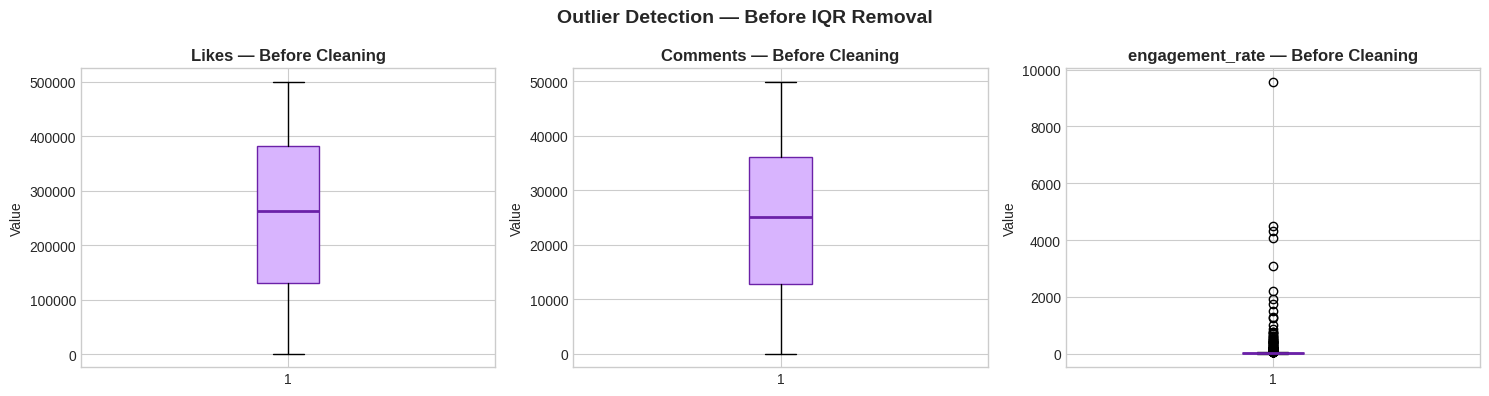

✅ Saved boxplots_before.png


In [7]:
# Visualize before outlier removal
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Likes', 'Comments', 'engagement_rate']):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=COLORS[1], color=COLORS[0]),
               medianprops=dict(color=COLORS[0], linewidth=2))
    ax.set_title(f'{col} — Before Cleaning', fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Outlier Detection — Before IQR Removal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_before.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved boxplots_before.png')

In [8]:
# Apply IQR outlier removal
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    total_removed = 0
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        removed = before - len(df_clean)
        total_removed += removed
        print(f'  {col}: removed {removed:,} outliers (range: {lower:.2f} to {upper:.2f})')
    return df_clean, total_removed

before_count = len(df)
df_clean, total_removed = remove_outliers_iqr(df, ['Likes', 'Comments', 'Views', 'Shares', 'engagement_rate'])

print(f'\n📊 Rows before: {before_count:,}')
print(f'🗑️  Total outliers removed: {total_removed:,}')
print(f'✅ Rows after: {len(df_clean):,}')

  Likes: removed 0 outliers (range: -243135.75 to 756246.25)
  Comments: removed 0 outliers (range: -22272.75 to 71163.25)
  Views: removed 0 outliers (range: -2751561.25 to 7480388.75)
  Shares: removed 0 outliers (range: -55109.75 to 154728.25)
  engagement_rate: removed 152 outliers (range: -24.25 to 62.47)

📊 Rows before: 1,212
🗑️  Total outliers removed: 152
✅ Rows after: 1,060


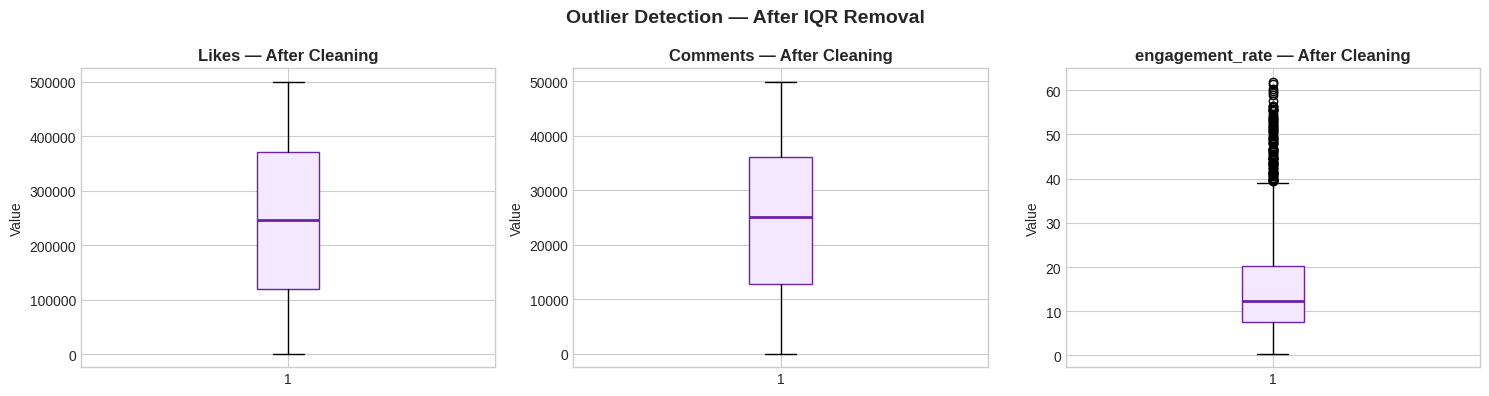

✅ Saved boxplots_after.png


In [9]:
# Visualize after outlier removal
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Likes', 'Comments', 'engagement_rate']):
    ax.boxplot(df_clean[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=COLORS[3], color=COLORS[0]),
               medianprops=dict(color=COLORS[0], linewidth=2))
    ax.set_title(f'{col} — After Cleaning', fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Outlier Detection — After IQR Removal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved boxplots_after.png')

## Step 6: Normalize Numeric Features

> **MinMaxScaler** scales all numeric values to a 0–1 range.  
> This ensures no single feature dominates the ML model due to scale differences.

In [10]:
# Columns to normalize
cols_to_normalize = ['Likes', 'Comments', 'Views', 'Shares', 'engagement_rate']

scaler = MinMaxScaler()
df_clean[cols_to_normalize] = scaler.fit_transform(df_clean[cols_to_normalize])

print('✅ Normalization complete! All numeric features scaled to 0–1 range.')
print('\nNormalized column ranges:')
for col in cols_to_normalize:
    print(f'  {col}: min={df_clean[col].min():.4f}, max={df_clean[col].max():.4f}')

✅ Normalization complete! All numeric features scaled to 0–1 range.

Normalized column ranges:
  Likes: min=0.0000, max=1.0000
  Comments: min=0.0000, max=1.0000
  Views: min=0.0000, max=1.0000
  Shares: min=0.0000, max=1.0000
  engagement_rate: min=0.0000, max=1.0000


## Step 7: Engineer Additional Features

In [11]:
# Feature 1: Hashtag length (number of characters in hashtag)
df_clean['hashtag_length'] = df_clean['Hashtag'].astype(str).apply(len)

# Feature 2: Is it a Video? (binary)
df_clean['is_video'] = df_clean['Content_Type'].astype(str).apply(
    lambda x: 1 if 'video' in x.lower() or 'reel' in x.lower() or 'shorts' in x.lower() else 0
)

# Feature 3: Encode Engagement_Level as number
engagement_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_clean['engagement_level_num'] = df_clean['Engagement_Level'].map(engagement_map)

# Feature 4: Encode Content_Type as numbers (for ML)
df_clean['content_type_encoded'] = pd.Categorical(df_clean['Content_Type']).codes

# Feature 5: Encode Region as numbers (for ML)
df_clean['region_encoded'] = pd.Categorical(df_clean['Region']).codes

print('✅ New features engineered:')
print('  - hashtag_length')
print('  - is_video')
print('  - engagement_level_num')
print('  - content_type_encoded')
print('  - region_encoded')
print(f'\n📊 Final shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

✅ New features engineered:
  - hashtag_length
  - is_video
  - engagement_level_num
  - content_type_encoded
  - region_encoded

📊 Final shape: 1,060 rows × 17 columns


## Step 8: Final Data Quality Check

In [12]:
print('📋 Final Dataset Info:')
print(f'  Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print(f'  Missing values: {df_clean.isnull().sum().sum()}')
print(f'  Duplicates: {df_clean.duplicated().sum()}')
print(f'\n🚀 Viral post distribution:')
print(df_clean['viral'].value_counts())
print(f'  Viral rate: {df_clean["viral"].mean()*100:.1f}%')
print(f'\n📊 Content Type distribution:')
print(df_clean['Content_Type'].value_counts())
print(f'\n🌍 Region distribution:')
print(df_clean['Region'].value_counts())

📋 Final Dataset Info:
  Shape: 1,060 rows × 17 columns
  Missing values: 0
  Duplicates: 0

🚀 Viral post distribution:
viral
0    969
1     91
Name: count, dtype: int64
  Viral rate: 8.6%

📊 Content Type distribution:
Content_Type
Video          190
Live Stream    183
Reel           180
Tweet          170
Post           169
Shorts         168
Name: count, dtype: int64

🌍 Region distribution:
Region
Canada       157
India        138
Germany      137
Australia    133
Brazil       132
USA          130
UK           130
Japan        103
Name: count, dtype: int64


In [13]:
# Preview final clean dataset
print('🔍 Final clean dataset preview:')
df_clean.head()

🔍 Final clean dataset preview:


,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level,engagement_rate,viral,hashtag_length,is_video,engagement_level_num,content_type_encoded,region_encoded
0,Post_2,Instagram,#Education,Shorts,India,0.8273,0.4294,0.6590,0.5457,Medium,0.1138,0,10,1,1,3,4
1,Post_6,Instagram,#Challenge,Shorts,Australia,0.2462,0.2710,0.8706,0.9445,Low,0.3256,0,10,1,0,3,0
2,Post_11,Instagram,#Comedy,Live Stream,Germany,0.8097,0.7599,0.4601,0.5057,High,0.1735,0,7,0,2,0,3
3,Post_27,Instagram,#Gaming,Video,India,0.8711,0.4235,0.2122,0.3640,Low,0.0869,0,7,1,0,5,4
4,Post_29,Instagram,#Gaming,Live Stream,Canada,0.3140,0.1818,0.7743,0.0562,Low,0.1624,0,7,0,0,0,2


## Step 9: Save Clean Dataset

In [14]:
# Save cleaned dataset
df_clean.to_csv('goviraliq_instagram_clean.csv', index=False)

print('✅ Clean dataset saved as goviraliq_instagram_clean.csv')
print(f'   Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print(f'\n📁 Files created this notebook:')
print('   - goviraliq_instagram_clean.csv')
print('   - boxplots_before.png')
print('   - boxplots_after.png')

✅ Clean dataset saved as goviraliq_instagram_clean.csv
   Shape: 1,060 rows × 17 columns

📁 Files created this notebook:
   - goviraliq_instagram_clean.csv
   - boxplots_before.png
   - boxplots_after.png


## Step 10: Cleaning Summary

In [15]:
print('=' * 55)
print('       GoViralIQ — Notebook 2 Summary')
print('=' * 55)
print(f'\n🗑️  Duplicates removed:      {df.duplicated().sum():,}')
print(f'🗑️  Outliers removed:         {before_count - len(df_clean):,}')
print(f'📊 Final dataset size:        {len(df_clean):,} rows')
print(f'🔢 Total features:            {df_clean.shape[1]} columns')
print(f'✅ Missing values remaining:  0')
print(f'🚀 Viral posts:               {df_clean["viral"].sum():,} ({df_clean["viral"].mean()*100:.1f}%)')
print('\n' + '=' * 55)
print('\n✅ Next: Notebook 03 — Data Visualization')

       GoViralIQ — Notebook 2 Summary

🗑️  Duplicates removed:      0
🗑️  Outliers removed:         152
📊 Final dataset size:        1,060 rows
🔢 Total features:            17 columns
✅ Missing values remaining:  0
🚀 Viral posts:               91 (8.6%)


✅ Next: Notebook 03 — Data Visualization
